# Chiou et al. (2025) 재구현 — 레코드 한 건을 눈으로 따라가기

**목적.** 계획서 3.3절이 재구현한 선행 연구
(Chiou et al., *Deep learning for intrapartum cardiotocography*, 2025)의 파이프라인이
**레코드 하나**에서 실제로 무엇을 하는지 모든 중간 단계를 그림으로 확인한다. 계산 로직은
전부 `preprocess.py` · `features.py` · `model.py`에서 import한다 — 이 노트북은 같은 코드의
**시각화 판**이며, 마지막 셀에서 552건 배치 결과(`log/ctu_features17.csv`,
`log/ctu_model_inputs.npz`)와 값이 일치함을 검증한다.

**샘플.** 레코드 **1001** (제대동맥혈 pH 7.14, 1분 Apgar 6 — 두 기준 모두 비정상).
`1-dataset-walkthrough`가 해부한 것과 같은 레코드다.

**명세의 준거.** 재구현의 기준 문서는 medRxiv 프리프린트
(doi:10.1101/2024.03.05.24303805) Appendix A·B다 — 출판본에는 단계 이름만 있는
전처리·특성 규칙이 프리프린트에는 수치까지 명시되어 있다.

**논문의 파이프라인은 두 갈래다.** 이 노트북도 같은 순서로 따라간다.

| | (A) 신경망 파이프라인 | (B) 규칙 기반 특성 파이프라인 |
|---|---|---|
| 코드 | `preprocess.py` → `model.py` | `features.py` |
| 결측 처리 | >15초는 **0 표지로 유지** + 결측 ≥50%인 5분 창은 0 재지정 (품질 평가) | 전부 선형 보간 |
| 평활 | 15포인트 Hamming 가중 이동평균, 유효 표본만 (A.1 명시) | 30초 rolling (유효 표본만) |
| 산출 | (2 × 1,800) 텐서 → CTG-net | 특성 17개 → XGBoost |
| 논문 위치 | Fig. 2·Methods·Appendix A.1 | Fig. 2G, Appendix A.2 |

**단계**
1. 원신호와 임상 라벨 — Eq. (1)의 세 라벨, 메타데이터 11속성
2. (A) 1단계: 양끝 결측 제거
3. (A) 2단계: 결측 15초 기준 분류 — 보간과 0 유지
4. (A) 3단계: Hamming 평활과 품질 재지정
5. (A) 4단계: 30분 크롭 — 기본 구간과 대안 구간
6. (A) 5·6단계: 1 Hz 다운샘플 + max-abs 스케일 → 모델 입력
7. (A) 학습 증강 — 무작위 크롭과 다중 스케일 노이즈
8. (B) 특성 파이프라인 — 전용 전처리, 반복 기저선, 이벤트 검출, 특성 17개
9. CTG-net 구조와 이 레코드의 순전파
10. **배치 결과와의 일치 검증**

## 0. 준비

계산 코드는 재구현 모듈에서 그대로 가져온다. 여기서 새로 정의하는 계산 함수는 없다.

In [1]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm

sys.path.insert(0, str(Path.cwd()))
from ctguhb import (
    METADATA_ATTRS, make_labels, metadata_frame, metadata_vector, parse_header, read_signals,
)
from preprocess import (
    CROP_MIN, FS, LONG_GAP_S, SMOOTH_WINDOW, augment_crops, crop_last_minutes,
    downsample_to_1hz, flag_low_quality, gap_runs, impute_short_gaps,
    make_model_input, maxabs_scale, preprocess_record, random_crop,
    sliding_crops_excluding_last, smooth, trim_edge_missing,
)
from features import (
    ACC_MIN_BPM, BASELINE_TOL, BASELINE_WIN_S, DEC_MIN_BPM, FEATURE_NAMES,
    classify_deceleration, detect_accelerations, detect_contractions,
    detect_decelerations, estimate_baseline, extract_features,
    preprocess_for_features,
)
from run_all import DATA, MAX_CROP_MISSING, MAX_CROP_MISSING_TXT

try:
    fm.findfont("NanumGothic", fallback_to_default=False)
    plt.rcParams["font.family"] = "NanumGothic"
except ValueError:
    pass
plt.rcParams["axes.unicode_minus"] = False

C_FHR, C_UC = "#e34948", "#2a78d6"
C_DECEL, C_ACCEL, C_BASE = "#eb6834", "#1baf7a", "#1c2430"
C_DROP, MUTED = "#8a94a0", "#5a6673"

RID = "1001"
print(f"데이터 경로: {DATA}")
print(f"샘플: 레코드 {RID}")

데이터 경로: /home/yabsed/Documents/summer26/fetalguard-ai/project/experiment-15/ctu-hub-ctgdb
샘플: 레코드 1001


## 1. 원신호와 임상 라벨

`.hea` 헤더에서 신호 명세와 임상 메타데이터를 읽고, `.dat`의 16-bit 정수를 체크섬으로
검증하며 읽는다(`ctguhb.read_signals`). 논문 Eq. (1)의 라벨은 세 가지다.

$$\text{ph} = [\,\mathrm{pH} < 7.20\,], \quad
\text{apgar} = [\,\mathrm{Apgar_1} < 7\,], \quad
\text{lor} = \text{ph} \lor \text{apgar}$$

모델 입력에는 파형 외에 산모·임신 관련 **메타데이터 11속성**이 함께 들어간다(Fig. 2g).

In [2]:
fhr_raw, uc_raw, meta, fs = read_signals(DATA / f"{RID}.hea")
record, signals, _ = parse_header(DATA / f"{RID}.hea")

print(f"레코드 {record['name']}: {record['n_signals']}채널 × {record['n_samples']:,}샘플 "
      f"@ {record['fs']:.0f} Hz = {record['n_samples'] / record['fs'] / 60:.1f}분")
for s in signals:
    print(f"  - {s['description']:4s} format {s['format']}, gain {s['gain']:g}, "
          f"checksum {s['checksum']} (검증 통과)")

meta_df = metadata_frame({RID: {"meta": meta}})
labels = make_labels(meta_df)
print(f"\npH {meta['pH']:.2f} → ph={labels['ph'][RID]}, "
      f"Apgar1 {meta['Apgar1']:.0f} → apgar={labels['apgar'][RID]}, "
      f"lor={labels['lor'][RID]}")
pd.DataFrame({"속성": METADATA_ATTRS, "값": metadata_vector(meta_df, RID)})

레코드 1001: 2채널 × 19,200샘플 @ 4 Hz = 80.0분
  - FHR  format 16, gain 100, checksum 20101 (검증 통과)
  - UC   format 16, gain 100, checksum 378 (검증 통과)

pH 7.14 → ph=1, Apgar1 6 → apgar=1, lor=1


,속성,값
0,Gest. weeks,37.0
1,Age,32.0
2,Gravidity,1.0
3,Parity,0.0
4,Diabetes,1.0
5,Hypertension,0.0
6,Preeclampsia,0.0
7,Liq. praecox,1.0
8,Pyrexia,0.0
9,Meconium,0.0


## 2. (A) 1단계 — 기록 앞/뒤의 결측 제거

FHR 값 **0은 심박수가 아니라 신호 소실**이다. 논문의 첫 단계는 기록 양끝의 연속 결측을
잘라내는 것이며, 동시 기록된 UC도 같은 구간을 제거한다(`trim_edge_missing`).

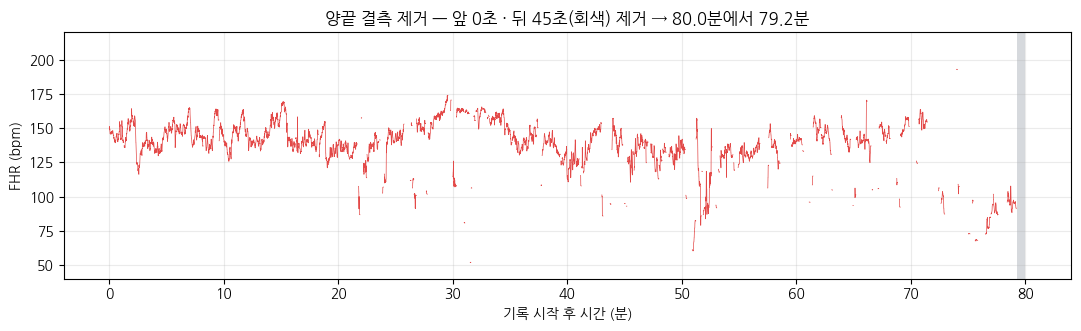

In [3]:
present = fhr_raw != 0
first, last = int(np.argmax(present)), len(present) - int(np.argmax(present[::-1]))
fhr_t, uc_t = trim_edge_missing(fhr_raw, uc_raw)

t_raw = np.arange(len(fhr_raw)) / FS / 60
fig, ax = plt.subplots(figsize=(13, 3.2))
ax.plot(t_raw, np.where(fhr_raw == 0, np.nan, fhr_raw), lw=0.5, color=C_FHR)
if first > 0:
    ax.axvspan(t_raw[0], t_raw[first], color=C_DROP, alpha=0.35, lw=0)
if last < len(fhr_raw):
    ax.axvspan(t_raw[last - 1], t_raw[-1], color=C_DROP, alpha=0.35, lw=0)
ax.set_ylim(40, 220)
ax.set_xlabel("기록 시작 후 시간 (분)")
ax.set_ylabel("FHR (bpm)")
ax.set_title(f"양끝 결측 제거 — 앞 {first / FS:.0f}초 · 뒤 {(len(fhr_raw) - last) / FS:.0f}초(회색) 제거 "
             f"→ {len(fhr_raw) / FS / 60:.1f}분에서 {len(fhr_t) / FS / 60:.1f}분")
ax.grid(alpha=0.25)
plt.show()

## 3. (A) 2단계 — 결측을 15초로 가른다

논문의 규칙: **15초 이하** 결측은 선형 보간, **15초 초과**는 보간하지 않고 **0으로 유지**한다.
길게 끊긴 구간을 억지로 메우면 없는 파형을 만들어내므로, 0이라는 표시를 남겨 모델이
"여기는 신호가 없었다"는 사실 자체를 학습하게 두는 선택이다(논문: preserving temporal
dependency).

결측 구간 108개 — ≤15초 90개(보간) · >15초 18개(0 유지)
결측 총량 21.4% 중 보간으로 채우는 몫 7.3%, 0으로 남는 몫 14.2%


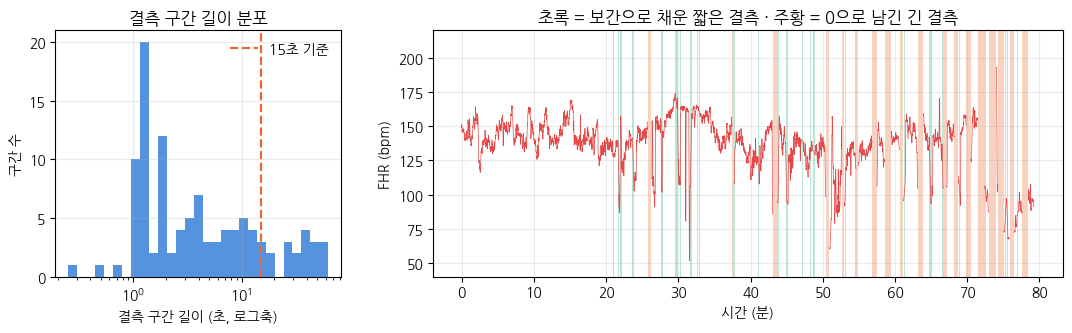

In [4]:
runs = gap_runs(fhr_t == 0)
lens_s = np.array([(e - s) / FS for s, e in runs])
short, long = lens_s <= LONG_GAP_S, lens_s > LONG_GAP_S
print(f"결측 구간 {len(runs)}개 — ≤{LONG_GAP_S}초 {short.sum()}개(보간) · "
      f">{LONG_GAP_S}초 {long.sum()}개(0 유지)")
print(f"결측 총량 {(fhr_t == 0).mean():.1%} 중 보간으로 채우는 몫 "
      f"{lens_s[short].sum() * FS / len(fhr_t):.1%}, 0으로 남는 몫 "
      f"{lens_s[long].sum() * FS / len(fhr_t):.1%}")

fhr_i = impute_short_gaps(fhr_t, int(LONG_GAP_S * FS))
uc_i = impute_short_gaps(uc_t, int(LONG_GAP_S * FS))

fig, axes = plt.subplots(1, 2, figsize=(13, 3.2),
                         gridspec_kw={"width_ratios": [1, 2.2]})
axes[0].hist(lens_s, bins=np.logspace(np.log10(0.25), np.log10(max(lens_s.max(), 1)), 30),
             color=C_UC, alpha=0.8)
axes[0].axvline(LONG_GAP_S, color=C_DECEL, lw=1.6, ls="--", label=f"{LONG_GAP_S}초 기준")
axes[0].set_xscale("log")
axes[0].set_xlabel("결측 구간 길이 (초, 로그축)")
axes[0].set_ylabel("구간 수")
axes[0].set_title("결측 구간 길이 분포")
axes[0].legend(frameon=False)

t_t = np.arange(len(fhr_t)) / FS / 60
axes[1].plot(t_t, np.where(fhr_i == 0, np.nan, fhr_i), lw=0.5, color=C_FHR)
for (s, e), is_long in zip(runs, long):
    axes[1].axvspan(t_t[s], t_t[e - 1], color=C_DECEL if is_long else C_ACCEL,
                    alpha=0.30, lw=0)
axes[1].set_ylim(40, 220)
axes[1].set_xlabel("시간 (분)")
axes[1].set_ylabel("FHR (bpm)")
axes[1].set_title("초록 = 보간으로 채운 짧은 결측 · 주황 = 0으로 남긴 긴 결측")
for ax in axes:
    ax.grid(alpha=0.25)
plt.show()

## 4. (A) 3단계 — Hamming 평활과 품질 재지정

평활 명세는 A.1에 있다: **길이 15포인트(3.75초) Hamming 창의 양방향 이동평균**
(Ogasawara et al.을 따른다고 명시). 단, 2단계가 남긴 결측 0은 심박수가 아니라
**표지**이므로 평균에 섞으면 안 된다 — 창 안의 **유효 표본만** 가중평균하고 결측
위치는 0으로 되돌리는 rolling mean(`smooth_masked`)을 쓴다. 덕분에 평활 후에도 긴
결측은 정확히 0으로 남아, 논문이 의도한 "여기는 신호가 없었다"는 정보가 모델
입력까지 살아서 전달된다.

A.1에는 평활과 짝을 이루는 **품질 평가** 규칙도 있다: 5분 슬라이딩 창(1분 보폭)에서
FHR 결측이 50% 이상인 창을 표시해 두었다가, 보간·평활이 끝난 뒤 해당 구간을 통째로
0으로 재지정한다(Asfaw et al. 방식) — 짧은 보간 조각들이 띄엄띄엄 이어진 저품질
구간이 "그럴듯한 신호"로 모델에 들어가는 것을 막는 장치다. `preprocess_record`가
지금까지의 단계 전부를 한 번에 수행한다.

품질 평가: 결측 ≥50% 창에 걸린 표본 14.2% (11.2분) → 보간·평활 후 0 재지정


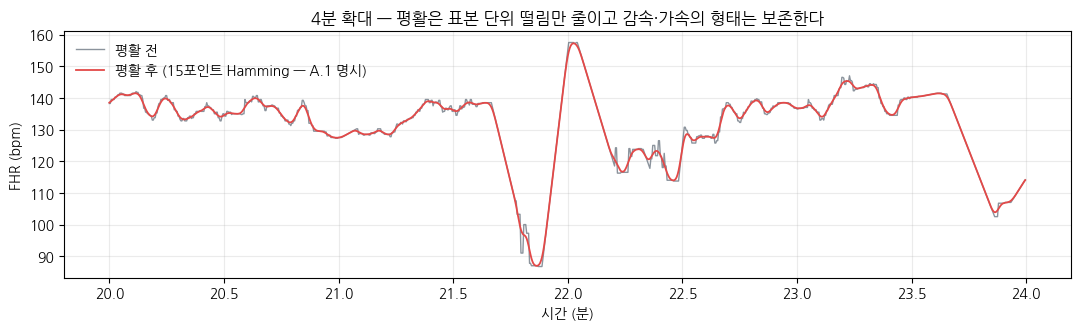

In [5]:
fhr_p, uc_p = preprocess_record(fhr_raw, uc_raw)
assert len(fhr_p) == len(fhr_t)
low_q = flag_low_quality(fhr_t, FS)
print(f"품질 평가: 결측 ≥50% 창에 걸린 표본 {low_q.mean():.1%} "
      f"({low_q.sum() / FS / 60:.1f}분) → 보간·평활 후 0 재지정")

zoom = slice(int(20 * 60 * FS), int(24 * 60 * FS))   # 4분 확대
tz = np.arange(len(fhr_t))[zoom] / FS / 60
fig, ax = plt.subplots(figsize=(13, 3.2))
ax.plot(tz, np.where(fhr_i[zoom] == 0, np.nan, fhr_i[zoom]), lw=1.0, color=MUTED,
        alpha=0.7, label="평활 전")
ax.plot(tz, np.where(fhr_p[zoom] == 0, np.nan, fhr_p[zoom]), lw=1.3, color=C_FHR,
        label=f"평활 후 ({SMOOTH_WINDOW}포인트 Hamming — A.1 명시)")
ax.set_xlabel("시간 (분)")
ax.set_ylabel("FHR (bpm)")
ax.set_title("4분 확대 — 평활은 표본 단위 떨림만 줄이고 감속·가속의 형태는 보존한다")
ax.legend(frameon=False)
ax.grid(alpha=0.25)
plt.show()

## 5. (A) 4단계 — 30분 크롭

기본 구간은 **분만 직전 마지막 30분**이다. 논문은 대안 구간 두 가지도 함께 실험했다.

1. 마지막 30분을 **제외한** 앞부분에서 슬라이딩 창 (사전학습·증강용)
2. 기록 전체에서 무작위 30분 창

이 데이터셋의 원신호는 전부 60분 이상이라 길이 때문에 탈락하는 레코드는 없다. 논문이
보고한 분석 대상 496건은 신호 **품질** 기준의 결과로 보이며, 크롭 창의 잔여 결측이
1/3 이하인 레코드만 남기면 정확히 496건이 된다(`run_all.py`, `log/summary.md`).

마지막 30분 크롭: 7,200샘플 · 잔여 결측 32.7% → 분석 대상 (기준 ≤1/3)
대안 구간 (1) 슬라이딩 창 20개, (2) 무작위 창 1개


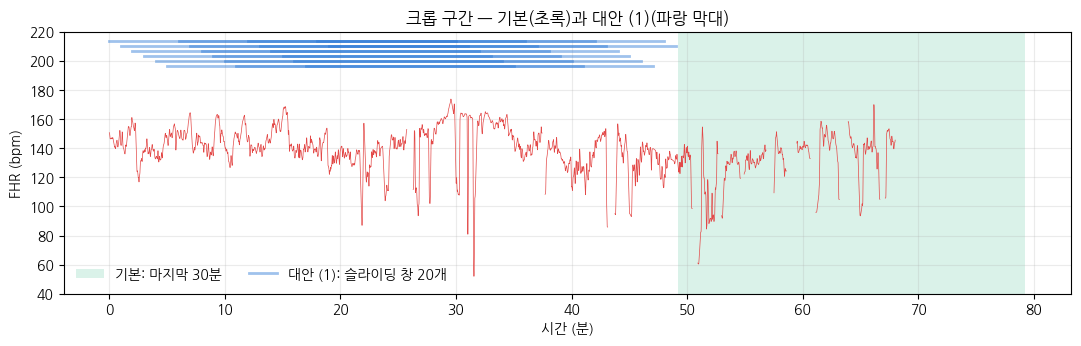

In [6]:
fhr_c = crop_last_minutes(fhr_p, fs=FS)
uc_c = crop_last_minutes(uc_p, fs=FS)
crop_miss = float((crop_last_minutes(fhr_i, fs=FS) == 0).mean())
slides = sliding_crops_excluding_last(fhr_p)
rnd = random_crop(fhr_p, np.random.default_rng(0))
print(f"마지막 {CROP_MIN}분 크롭: {len(fhr_c):,}샘플 · 잔여 결측 {crop_miss:.1%} "
      f"→ {'분석 대상' if crop_miss <= MAX_CROP_MISSING else '제외'} "
      f"(기준 ≤{MAX_CROP_MISSING_TXT})")
print(f"대안 구간 (1) 슬라이딩 창 {len(slides)}개, (2) 무작위 창 1개")

t_p = np.arange(len(fhr_p)) / FS / 60
fig, ax = plt.subplots(figsize=(13, 3.4))
ax.plot(t_p, np.where(fhr_p == 0, np.nan, fhr_p), lw=0.5, color=C_FHR)
ax.axvspan(t_p[-1] - CROP_MIN, t_p[-1], color=C_ACCEL, alpha=0.16, lw=0,
           label=f"기본: 마지막 {CROP_MIN}분")
for i in range(len(slides)):     # 1분 간격 → i번째 창은 i분에서 시작
    ax.plot([i, i + CROP_MIN], [214 - (i % 6) * 3.5] * 2, lw=2.0,
            color=C_UC, alpha=0.45,
            label=f"대안 (1): 슬라이딩 창 {len(slides)}개" if i == 0 else None)
ax.set_ylim(40, 220)
ax.set_xlabel("시간 (분)")
ax.set_ylabel("FHR (bpm)")
ax.set_title("크롭 구간 — 기본(초록)과 대안 (1)(파랑 막대)")
ax.legend(frameon=False, loc="lower left", ncol=2)
ax.grid(alpha=0.25)
plt.show()

## 6. (A) 5·6단계 — 1 Hz 다운샘플과 max-abs 스케일 → 모델 입력

4 Hz 30분(7,200포인트)을 4포인트 블록 평균으로 **1 Hz 1,800포인트**로 줄이고, 채널별
최대절대값으로 나눈다. 결과가 CTG-net의 입력 텐서 **(2, 1800)**이다.

모델 입력 (2, 1800) float32 — 채널별 최대절대값 FHR 169.9 bpm, UC 125.1


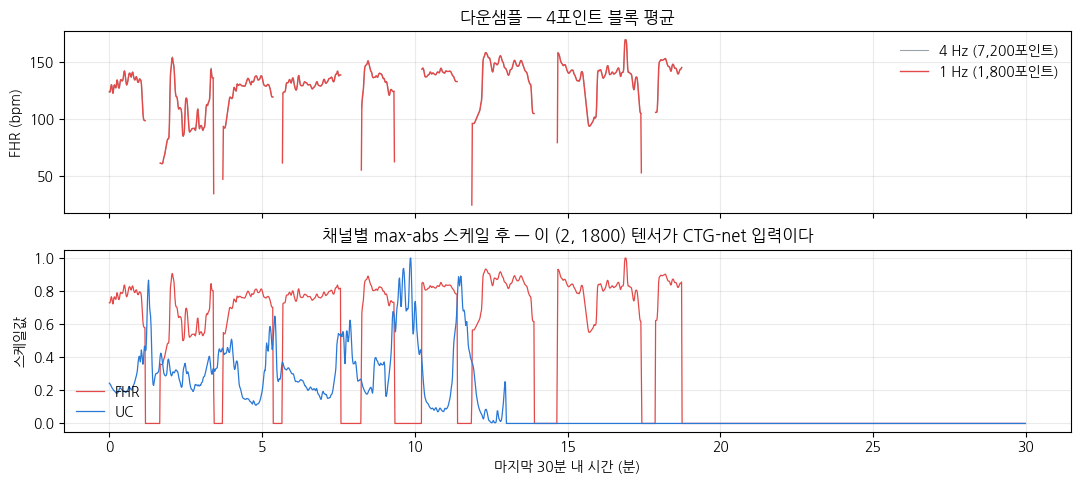

In [7]:
fhr_d, uc_d = downsample_to_1hz(fhr_c), downsample_to_1hz(uc_c)
fhr_s, uc_s = maxabs_scale(fhr_d, uc_d)
x = make_model_input(fhr_p, uc_p)
assert np.allclose(x, np.stack([fhr_s, uc_s])), "make_model_input과 단계별 계산 불일치"
print(f"모델 입력 {x.shape} {x.dtype} — 채널별 최대절대값 "
      f"FHR {np.abs(fhr_d).max():.1f} bpm, UC {np.abs(uc_d).max():.1f}")

fig, axes = plt.subplots(2, 1, figsize=(13, 5.2), sharex=True)
t4 = np.arange(len(fhr_c)) / FS / 60
t1 = np.arange(x.shape[1]) / 60
axes[0].plot(t4, np.where(fhr_c == 0, np.nan, fhr_c), lw=0.8, color=MUTED, alpha=0.6,
             label="4 Hz (7,200포인트)")
axes[0].plot(t1, np.where(fhr_d == 0, np.nan, fhr_d), lw=1.0, color=C_FHR,
             label="1 Hz (1,800포인트)")
axes[0].set_ylabel("FHR (bpm)")
axes[0].set_title("다운샘플 — 4포인트 블록 평균")
axes[0].legend(frameon=False)
axes[1].plot(t1, x[0], lw=0.9, color=C_FHR, label="FHR")
axes[1].plot(t1, x[1], lw=0.9, color=C_UC, label="UC")
axes[1].set_ylabel("스케일값")
axes[1].set_xlabel(f"마지막 {CROP_MIN}분 내 시간 (분)")
axes[1].set_title("채널별 max-abs 스케일 후 — 이 (2, 1800) 텐서가 CTG-net 입력이다")
axes[1].legend(frameon=False, loc="lower left")
for ax in axes:
    ax.grid(alpha=0.25)
plt.show()

## 7. (A) 학습 증강 — 무작위 크롭과 다중 스케일 노이즈

증강 명세는 A.1에 있다(Zhou et al. 방식). 전처리 완료(4 Hz) 신호에서 —

- **무작위 크롭 10개/레코드**: 마지막 30분의 시작점을 0~4분 균등추출로 앞당긴다
- **채널별 베르누이 추첨**: 전역 노이즈(신호 전체에 $\mathcal{N}(0,\,4)$) 또는
  국소 노이즈(1~5개 구간, 구간 경계 무작위)

증강 표본은 **학습 전용**이고, 검증·테스트는 결정론적 마지막 30분 크롭(무노이즈)을
쓴다. 국소 노이즈의 분산은 논문에 없어 전역과 같은 값(4)이 **[재구현 선택]**이다.

증강 크롭 10개 (레코드당, A.1 명시) — 4 Hz 원척도에서 생성 후 평가 크롭과 동일하게 1 Hz 다운샘플 + max-abs 스케일


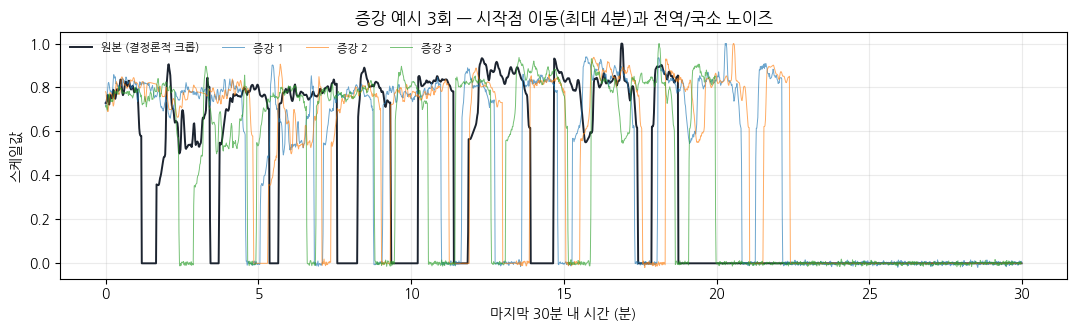

In [8]:
rng = np.random.default_rng(0)
crops = augment_crops(fhr_p, uc_p, rng)
print(f"증강 크롭 {len(crops)}개 (레코드당, A.1 명시) — 4 Hz 원척도에서 생성 후 "
      "평가 크롭과 동일하게 1 Hz 다운샘플 + max-abs 스케일")

fig, ax = plt.subplots(figsize=(13, 3.2))
ax.plot(t1, x[0], lw=1.4, color=C_BASE, label="원본 (결정론적 크롭)")
for i, (fc, tc_) in enumerate(crops[:3]):
    fd, td = downsample_to_1hz(fc), downsample_to_1hz(tc_)
    fs_, _ts = maxabs_scale(fd, td)
    ax.plot(t1, fs_, lw=0.7, alpha=0.65, label=f"증강 {i + 1}")
ax.set_xlabel(f"마지막 {CROP_MIN}분 내 시간 (분)")
ax.set_ylabel("스케일값")
ax.set_title("증강 예시 3회 — 시작점 이동(최대 4분)과 전역/국소 노이즈")
ax.legend(frameon=False, ncol=4, fontsize=8)
ax.grid(alpha=0.25)
plt.show()

## 8. (B) 규칙 기반 특성 파이프라인

여기서부터는 다른 갈래다. 논문은 FIGO 가이드라인(Ayres-de-Campos et al., 2015)에 따른
특성 **17개**를 뽑아 XGBoost와 비교했다(Fig. 3g, Table 1 첫 행).

### 8.1 전용 전처리 — 평활과 결측의 상호작용

논문 명세는 순서가 명확하다: 짧은 결측(≤15초) 보간 → **120포인트(30초) rolling window
평활** → 긴 결측(>15초)도 선형 보간. 평활 시점에 긴 결측이 아직 신호에 남아 있으므로,
"rolling window"를 어떻게 구현하느냐가 결과를 가른다.

결측이 표시된 신호의 rolling mean은 창 안의 **유효 표본만** 평균하는 것이 표준이다
(pandas `rolling(120, min_periods=1).mean()`이 NaN을 건너뛰는 것과 동일 —
`preprocess.smooth_masked`). 반면 0을 값으로 취급하는 단순 합성곱을 걸면 두 가지
인공물이 생긴다.

1. 결측 경계 앞뒤 15초의 **유효 표본이 0 쪽으로 끌려 내려간다**
2. 긴 결측이 0이 아닌 완만한 계곡으로 바뀌어, 뒤이은 "남은 결측 선형 보간"이 그 구간을
   더 이상 결측으로 **인식하지 못한다**

그 결과 기저선이 수십 bpm 낮게 잡히고 없는 감속이 잡힌다. 아래 셀이 두 구현을 같은
구간에서 비교한다 — 이 저장소의 초기 버전이 실제로 갖고 있던 결함이며, 반례로 남겨 둔다.

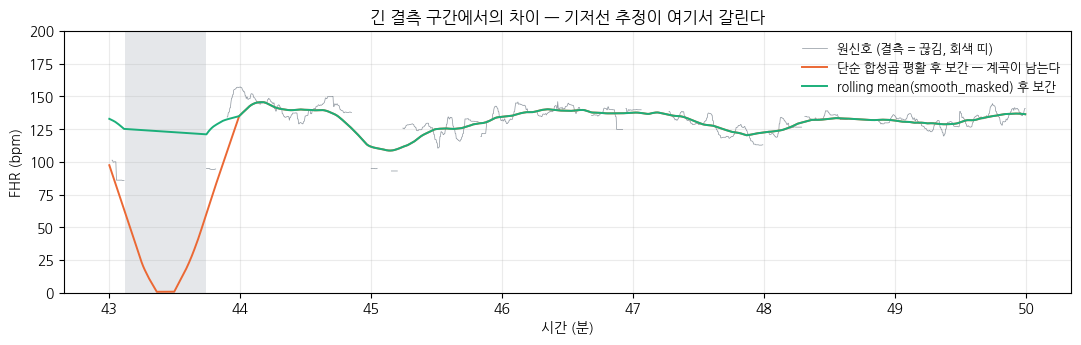

마지막 30분 기저선 — 그냥 평활 91.4 bpm vs smooth_masked 136.2 bpm (차이 +44.8)


In [9]:
naive = smooth(impute_short_gaps(fhr_t, int(LONG_GAP_S * FS)), int(30 * FS))
naive = impute_short_gaps(naive, len(naive))
fhr_f, uc_f = preprocess_for_features(fhr_t, uc_t)

nz = slice(int(43 * 60 * FS), int(50 * 60 * FS))
tn = np.arange(len(fhr_t))[nz] / FS / 60
fig, ax = plt.subplots(figsize=(13, 3.4))
for (s, e) in gap_runs(fhr_t == 0):
    if (e - s) > LONG_GAP_S * FS and nz.start <= s < nz.stop:
        ax.axvspan(t_t[s], t_t[e - 1], color=C_DROP, alpha=0.22, lw=0)
ax.plot(tn, np.where(fhr_t[nz] == 0, np.nan, fhr_t[nz]), lw=0.5, color=MUTED,
        alpha=0.7, label="원신호 (결측 = 끊김, 회색 띠)")
ax.plot(tn, naive[nz], lw=1.4, color=C_DECEL, label="단순 합성곱 평활 후 보간 — 계곡이 남는다")
ax.plot(tn, fhr_f[nz], lw=1.4, color=C_ACCEL, label="rolling mean(smooth_masked) 후 보간")
ax.set_ylim(0, 200)
ax.set_xlabel("시간 (분)")
ax.set_ylabel("FHR (bpm)")
ax.set_title("긴 결측 구간에서의 차이 — 기저선 추정이 여기서 갈린다")
ax.legend(frameon=False, fontsize=9)
ax.grid(alpha=0.25)
plt.show()

b_naive, _ = estimate_baseline(crop_last_minutes(naive, fs=FS), FS)
b_fixed, _ = estimate_baseline(crop_last_minutes(fhr_f, fs=FS), FS)
print(f"마지막 {CROP_MIN}분 기저선 — 그냥 평활 {b_naive:.1f} bpm vs "
      f"smooth_masked {b_fixed:.1f} bpm (차이 {b_fixed - b_naive:+.1f})")

### 8.2 반복 기저선

A.2 명세: 10분 창의 **평균**(average value)으로 초기 추정한 뒤, 가속·감속으로 판정된
구간을 제외하며 평균을 다시 계산하는 과정을 **변화량이 0.5 bpm 미만**이 될 때까지
반복한다. 30분 크롭의 어느 10분을 초기 창으로 쓰는지는 명시가 없어, 유효 표본의
앞 10분이 **[재구현 선택]**이다.

반복 궤적 B^(k): 124.12 → 128.58 → 132.06 → 134.40 → 135.71 → 136.20 → 수렴 136.20 bpm


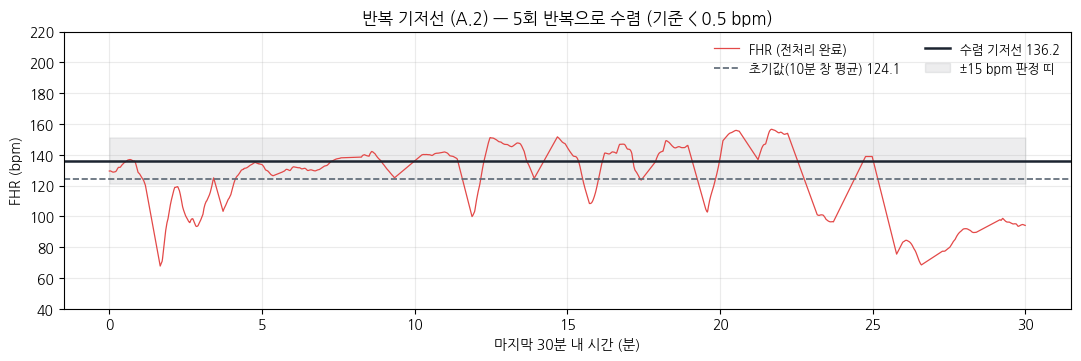

In [10]:
fhr_fc = crop_last_minutes(fhr_f, fs=FS)
uc_fc = crop_last_minutes(uc_f, fs=FS)

valid = fhr_fc[fhr_fc > 0]
trace = [float(np.mean(valid[:min(int(BASELINE_WIN_S * FS), len(valid))]))]  # 10분 창 평균
while len(trace) < 50:
    dev = fhr_fc - trace[-1]
    keep = ~(((dev >= ACC_MIN_BPM) | (dev <= -DEC_MIN_BPM)) | (fhr_fc == 0))
    new = float(np.mean(fhr_fc[keep])) if keep.any() else trace[-1]
    if abs(new - trace[-1]) < BASELINE_TOL:
        trace.append(new)
        break
    trace.append(new)

baseline, keep = estimate_baseline(fhr_fc, FS)
assert abs(baseline - trace[-1]) < BASELINE_TOL, "모듈 함수와 반복 결과 불일치"
print("반복 궤적 B^(k):", " → ".join(f"{b:.2f}" for b in trace), f"→ 수렴 {baseline:.2f} bpm")

tc = np.arange(len(fhr_fc)) / FS / 60
fig, ax = plt.subplots(figsize=(13, 3.6))
ax.plot(tc, fhr_fc, lw=0.9, color=C_FHR, label="FHR (전처리 완료)")
ax.axhline(trace[0], color=MUTED, lw=1.2, ls="--", label=f"초기값(10분 창 평균) {trace[0]:.1f}")
ax.axhline(baseline, color=C_BASE, lw=1.8, label=f"수렴 기저선 {baseline:.1f}")
ax.fill_between(tc, baseline - DEC_MIN_BPM, baseline + ACC_MIN_BPM, color=C_BASE,
                alpha=0.08, label="±15 bpm 판정 띠")
ax.set_ylim(40, 220)
ax.set_xlabel(f"마지막 {CROP_MIN}분 내 시간 (분)")
ax.set_ylabel("FHR (bpm)")
ax.set_title(f"반복 기저선 (A.2) — {len(trace) - 1}회 반복으로 수렴 (기준 < {BASELINE_TOL} bpm)")
ax.legend(frameon=False, ncol=2, fontsize=9)
ax.grid(alpha=0.25)
plt.show()

### 8.3 이벤트 검출과 감속 유형 분류

A.2가 명시하는 규칙은 다음과 같다.

- **수축**: "종 모양 완만한 상승, 총 지속 45~120초"인 UC 피크(`detect_contractions`)
- **가속**: 기저선 +15 bpm 초과 상승이 15초 초과 지속, **개시→정점 30초 미만**,
  총 지속 10분 미만
- **감속**: 기저선 −15 bpm 초과 하강이 15초 초과 지속
- **후기감속**: 감속 **개시**가 최근접 수축의 **개시** 20초 후 ~ 수축 종료 전
- 후기가 아닌 감속은 **지속시간**으로 나눈다: 조기(< 3분) / 장기(3~5분) /
  중증(> 5분) — 중증이 심박 수치가 아니라 지속시간 기준임에 주의
- **변동감속**: 개시→최저점 30초 미만. 위 분류와 **독립**으로 계수되므로
  유형 수의 합은 감속 수와 다를 수 있다

수축 피크 탐지 파라미터와 '최근접 수축'의 거리 척도만 **[재구현 선택]**이다.

In [11]:
contractions = detect_contractions(uc_fc, FS)
accs = detect_accelerations(fhr_fc, baseline, FS)
decs = detect_decelerations(fhr_fc, baseline, FS)

KOR = {"early": "조기", "late": "후기", "prolonged": "장기", "severe": "중증"}
rows = []
for i, (s, e) in enumerate(decs, 1):
    nadir = s + int(np.argmin(fhr_fc[s:e]))
    main, is_var = classify_deceleration(s, e, nadir, contractions, FS)
    types = [KOR[main]] + (["변동"] if is_var else [])
    rows.append({"감속": i, "시작(분)": s / FS / 60, "지속(초)": (e - s) / FS,
                 "개시→최저(초)": (nadir - s) / FS,
                 "최저(bpm)": fhr_fc[nadir], "깊이(bpm)": baseline - fhr_fc[nadir],
                 "유형": "+".join(types)})
print(f"감속 {len(decs)}회 · 가속 {len(accs)}회 · 수축 {len(contractions)}회")
pd.DataFrame(rows).round(2)

감속 7회 · 가속 2회 · 수축 4회


,감속,시작(분),지속(초),개시→최저(초),최저(bpm),깊이(bpm),유형
0,1,1.17,132.50,30.00,67.71,68.49,조기
1,2,3.47,36.25,15.25,103.22,32.98,후기+변동
2,3,11.60,32.00,16.50,99.81,36.39,후기+변동
3,4,15.54,27.00,11.25,108.28,27.92,조기+변동
4,5,19.30,31.00,17.00,102.76,33.44,조기+변동
5,6,22.81,91.00,54.00,96.40,39.81,조기
6,7,25.21,287.50,83.25,68.46,67.75,장기


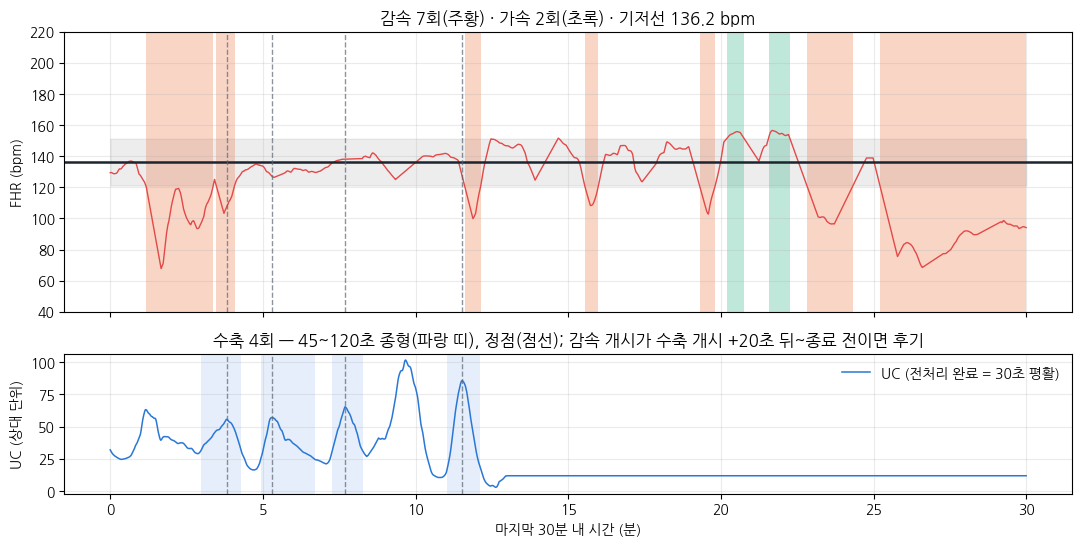

In [12]:
fig, axes = plt.subplots(2, 1, figsize=(13, 6.0), sharex=True,
                         gridspec_kw={"height_ratios": [2, 1]})
ax = axes[0]
ax.plot(tc, fhr_fc, lw=1.0, color=C_FHR)
ax.axhline(baseline, color=C_BASE, lw=1.8)
ax.fill_between(tc, baseline - DEC_MIN_BPM, baseline + ACC_MIN_BPM, color=C_BASE, alpha=0.08)
for s, e in decs:
    ax.axvspan(tc[s], tc[e - 1], color=C_DECEL, alpha=0.28, lw=0)
for s, e in accs:
    ax.axvspan(tc[s], tc[e - 1], color=C_ACCEL, alpha=0.28, lw=0)
ax.set_ylim(40, 220)
ax.set_ylabel("FHR (bpm)")
ax.set_title(f"감속 {len(decs)}회(주황) · 가속 {len(accs)}회(초록) · 기저선 {baseline:.1f} bpm")
ax2 = axes[1]
ax2.plot(tc, uc_fc, lw=1.1, color=C_UC, label="UC (전처리 완료 = 30초 평활)")
for on, p, end in contractions:
    ax2.axvspan(tc[on], tc[min(end, len(tc) - 1)], color=C_UC, alpha=0.12, lw=0)
    for a in axes:
        a.axvline(tc[p], color=MUTED, ls="--", lw=1.0, alpha=0.7)
ax2.set_ylabel("UC (상대 단위)")
ax2.set_xlabel(f"마지막 {CROP_MIN}분 내 시간 (분)")
ax2.set_title(f"수축 {len(contractions)}회 — 45~120초 종형(파랑 띠), 정점(점선); "
              "감속 개시가 수축 개시 +20초 뒤~종료 전이면 후기")
ax2.legend(frameon=False)
for a in axes:
    a.grid(alpha=0.25)
plt.show()

### 8.4 특성 17개

In [13]:
feats = extract_features(fhr_fc, uc_fc, FS)
GROUPS = {
    "자궁수축": ["n_uc"],
    "기저선·변이도": ["baseline", "baseline_variability"],
    "가속·감속": ["n_accelerations", "n_decelerations", "n_early_decelerations",
                "n_variable_decelerations", "n_severe_decelerations",
                "n_late_decelerations", "n_prolonged_decelerations"],
    "히스토그램": ["hist_width", "hist_min", "hist_max", "hist_median",
               "hist_mean", "hist_mode", "hist_std"],
}
assert sum(len(v) for v in GROUPS.values()) == len(FEATURE_NAMES) == 17
fmap = dict(zip(FEATURE_NAMES, feats))
pd.DataFrame([{"그룹": g, "특성": k, "값": round(float(fmap[k]), 3)}
              for g, keys in GROUPS.items() for k in keys])

,그룹,특성,값
0,자궁수축,n_uc,4.000
1,기저선·변이도,baseline,136.204
2,기저선·변이도,baseline_variability,2.702
3,가속·감속,n_accelerations,2.000
4,가속·감속,n_decelerations,7.000
5,가속·감속,n_early_decelerations,4.000
6,가속·감속,n_variable_decelerations,4.000
7,가속·감속,n_severe_decelerations,0.000
8,가속·감속,n_late_decelerations,2.000
9,가속·감속,n_prolonged_decelerations,1.000


## 9. CTG-net — 구조와 순전파

Ogasawara et al. (2021)의 CTG-net을 Chiou et al.이 변형해 썼다. 30초-bin 시간 합성곱 →
depthwise 합성곱(FHR-UC 관계) → separable 합성곱 → dense(sigmoid)로, 파라미터가 수천 개
수준인 작은 모델이다. 논문은 필터 수를 아키텍처 탐색(무작위 500개 구성)으로 정했고 커널·풀
크기를 공개하지 않아 기본값은 **[재구현 선택]**이다.

학습과 성능 수치는 이 저장소의 범위 밖이다 — 3.3절의 목적은 선행 연구 결과의 정확한
전달이며, 공개하는 것은 재구현 코드까지다. 여기서는 **구조가 논문 명세와 맞물리는지**
(파라미터 수, 입출력 형태)만 확인한다.

In [14]:
import warnings

try:
    with warnings.catch_warnings():
        warnings.simplefilter("ignore")
        import torch
    from model import build_model, count_parameters

    rows = []
    for ch in ("fhr_uc", "fhr", "uc"):
        m = build_model(ch)
        xt = torch.from_numpy(x[None] if ch == "fhr_uc" else x[None, :1])
        with torch.no_grad():
            out = m(xt)
        rows.append({"입력": ch, "채널": 1 if ch != "fhr_uc" else 2,
                     "파라미터": count_parameters(m), "flatten_dim": m.flatten_dim,
                     "출력 로짓": float(out[0]),
                     "이상 확률": float(torch.sigmoid(out)[0])})
    m_meta = build_model("fhr_uc", n_metadata=len(METADATA_ATTRS))
    with torch.no_grad():
        out = m_meta(torch.from_numpy(x[None]),
                     torch.from_numpy(metadata_vector(meta_df, RID)[None]))
    rows.append({"입력": "fhr_uc + metadata", "채널": 2,
                 "파라미터": count_parameters(m_meta), "flatten_dim": m_meta.flatten_dim,
                 "출력 로짓": float(out[0]), "이상 확률": float(torch.sigmoid(out)[0])})
    print("주의: 학습하지 않은 무작위 초기화 모델이다 — 확률값에 의미는 없고, "
          "형태가 맞물리는지만 본다.")
    display(pd.DataFrame(rows).round(4))
except ImportError as e:
    print(f"torch 미설치 — 이 셀은 건너뛴다 ({e}).")
    print("model.py의 구조 점검은 `python model.py`로도 확인할 수 있다.")

주의: 학습하지 않은 무작위 초기화 모델이다 — 확률값에 의미는 없고, 형태가 맞물리는지만 본다.


,입력,채널,파라미터,flatten_dim,출력 로짓,이상 확률
0,fhr_uc,2,2145,1728,-0.4167,0.3973
1,fhr,1,2025,1728,-0.4088,0.3992
2,uc,1,2025,1728,0.2806,0.5697
3,fhr_uc + metadata,2,2156,1739,0.0425,0.5106


## 10. 배치 결과와의 일치 검증

`run_all.py`가 552건 전체를 돌려 만든 산출물에서 이 레코드의 행을 꺼내, 위에서 단계별로
계산한 값과 대조한다. 노트북의 시각화 경로와 배치 경로가 같은 코드임을 확인하는 셀이다.

In [15]:
csv = pd.read_csv(Path("log") / "ctu_features17.csv")
row = csv[csv["record_id"] == int(RID)].iloc[0]
diffs = {k: (float(fmap[k]), float(row[k])) for k in FEATURE_NAMES
         if not np.isclose(float(fmap[k]), float(row[k]), rtol=1e-5, atol=1e-5)}
assert not diffs, f"배치 CSV와 불일치: {diffs}"
print(f"특성 17개 일치 — {len(csv)}건 × 17개 중 레코드 {RID}의 행")

npz = np.load(Path("log") / "ctu_model_inputs.npz")
i = int(np.where(npz["record_ids"] == RID)[0][0])
assert np.allclose(npz["X"][i], x), "배치 NPZ와 모델 입력 불일치"
print(f"모델 입력 일치 — NPZ {npz['X'].shape} 중 {i}번째 "
      f"(분석 대상 표시 usable={bool(npz['usable'][i])})")
print(f"\n배치 산출물 규모: 특성 CSV {len(csv)}행 · "
      f"모델 입력 {npz['X'].shape} · 분석 대상 {int(npz['usable'].sum())}건")

특성 17개 일치 — 552건 × 17개 중 레코드 1001의 행
모델 입력 일치 — NPZ (552, 2, 1800) 중 0번째 (분석 대상 표시 usable=True)

배치 산출물 규모: 특성 CSV 552행 · 모델 입력 (552, 2, 1800) · 분석 대상 496건


## 정리

- 논문의 두 파이프라인을 레코드 1001 하나에서 **모든 중간 단계까지** 재현하고, 그 결과가
  552건 배치 산출물과 일치함을 검증했다.
- 552건 전체의 변환 결과: `log/ctu_features17.csv` · `log/ctu_model_inputs.npz`
  (요약: `log/summary.md`)
- 레코드별 판정 근거 시각화 552장: `figures/records/` (`make_record_figures.py`)
- 계획서 그림 3-3-1: `figures/11_preprocessing.png` (`make_figures.py`)
- 평활은 두 갈래 모두 결측 표지를 존중하는 rolling mean(`preprocess.smooth_masked`)으로
  통일했다 — 논문의 "rolling window" 표기와 "0 = 결측 표지" 의도에 대한 충실한 해석이며,
  0을 값으로 취급하는 단순 합성곱이 왜 틀리는지는 8.1절이 반례로 보인다.
- 명세의 준거는 medRxiv 프리프린트 Appendix A·B다. 평활 창(15포인트 Hamming), 품질
  평가(5분 창 50%), 증강(크롭 10개·±4분·전역 분산 4), 감속 유형 규칙(후기 = 수축 개시
  +20초, 조기/장기/중증 = 지속시간, 변동 = 개시→최저점 30초)은 전부 프리프린트에
  명시된 값이다.
- 프리프린트에도 없어 **[재구현 선택]**으로 남긴 지점: UC 피크 탐지 파라미터와 경계
  산정, 기저선 초기 10분 창의 위치, 변이도 극점 산정, '최근접 수축'의 거리 척도,
  국소 노이즈 분산, CTG-net의 커널·풀 크기. 각 선택은 코드 주석에 근거와 함께 적혀
  있다.